### Prepare Data

#### Import

In [1]:
import warnings 

import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
# df = pd.read_csv("entrenamiento.csv")

In [3]:
import csv

input_file = "entrenamiento.csv"
output_file = "entrenamiento_parsed.csv"

with open(input_file, "r", encoding="utf-8", newline="") as infile, \
     open(output_file, "w", encoding="utf-8", newline="") as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    header = next(reader)
    writer.writerow(header)

    repaired = 0
    valid = 0

    for row in reader:

        if len(row) == 25:
            writer.writerow(row)
            valid += 1

        elif len(row) > 25:
            # Reconstruct description
            parsed_row = (row[:21]+ [",".join(row[21:-3])]+ row[-3:])

            writer.writerow(parsed_row)
            repaired += 1

In [4]:
data = pd.read_csv("entrenamiento_parsed.csv")
# data.info()

In [5]:
# data.head()

##### Chi-square test

In [6]:
from scipy.stats import chi2_contingency
import numpy as np

### Hypotheses

**Null hypothesis** (H₀): There is no relationship between `property_type` and `operation_type` (they are independent).

**Alternative hypothesis** (H₁): There is a significant relationship between `property_type` and `operation_type`.

In [7]:
# Contingency table
table = pd.crosstab(data['property_type'], data['operation_type'])

In [8]:
# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 146910.8623474115
p-value: 0.0
Degrees of freedom: 18


Since p-value = 0 < 0.05 → Reject H₀ ; hence a significant relationship between `property_type` and `operation_type`.

In [9]:
# Effect size: Cramér's V
n = table.sum().sum()
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

print("Cramér's V:", cramers_v)

Cramér's V: 0.2539563372551448


In [10]:
# columns = ['lat', 'lon','l1', 'l2', 'l3', 'l4', 'rooms', 'bedrooms', 'bathrooms','surface_total', 'surface_covered', 'currency', 'price']
columns = ['lat', 'lon','l1', 'l2', 'l3', 'l4', 'surface_total', 'surface_covered', 'currency', 'price']

In [11]:
df = data[columns]

In [12]:
# df.describe()

In [13]:
def preprocess(df):
    # Create a copy to prevent SettingWithCopyWarning
    df_processed = df.copy()

    # Swap swapped lat/lon column headers
    df_processed = df_processed.rename(columns={"lat": "lon", "lon": "lat"})

    # Ensure price is numeric
    df_processed["price"] = pd.to_numeric(df_processed["price"], errors="coerce")

    # Convert all currencies to USD as at August 10, 2026
    exchange_rates = {"USD": 1.0, "ARS": 1498.25, "UYU": 40.25, "PEN": 3.38}
    df_processed["price_usd"] = df_processed["price"] / df_processed["currency"].map(exchange_rates)

    # Subset data: Properties in "Capital Federal" priced above 500,000 USD
    mask_cf = df_processed["l2"] == "Capital Federal"
    mask_price = df_processed["price_usd"] > 500_000
    df_processed = df_processed[mask_cf & mask_price]

    # Subset data: Remove outliers for "surface_covered"
    low, high = df_processed["surface_covered"].quantile([0.1, 0.9])
    mask_area = df_processed["surface_covered"].between(low, high)
    df_processed = df_processed[mask_area]

    # Rename column 'l3'
    df_processed = df_processed.rename(columns={"l3": "neighborhood"})

    # Drop columns with high nulls, multicollinearity, redundancy
    # df_processed = df_processed.drop(columns=["l4", "rooms"])
    df_processed = df_processed.drop(columns=["l4"])


    # Drop columns
    df_processed = df_processed.drop(columns=["l1", "l2", "currency", "price"])

    # Fill Numeric columns by → median
    num_cols = df_processed.select_dtypes(include="number").columns
    df_processed[num_cols] = SimpleImputer(strategy="median").fit_transform(df_processed[num_cols])
    
    # Fill Categorical columns by → most frequent value
    cat_cols = df_processed.select_dtypes(exclude="number").columns
    df_processed[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df_processed[cat_cols])

    return df_processed

In [14]:
df_processed = preprocess(df)

In [15]:
df_processed.head()

,lon,lat,neighborhood,surface_total,surface_covered,price_usd
92,-58.421588,-34.588131,Puerto Madero,135.0,135.0,890000.0
136,-58.447588,-34.566724,Belgrano,206.0,130.0,990000.0
242,-58.360130,-34.613297,Puerto Madero,150.0,138.0,1020000.0
310,-58.363594,-34.604894,Puerto Madero,198.0,187.0,1200000.0
400,-58.360806,-34.610180,Puerto Madero,188.0,188.0,1200000.0


In [16]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9674 entries, 92 to 1138943
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lon              9674 non-null   float64
 1   lat              9674 non-null   float64
 2   neighborhood     9674 non-null   object 
 3   surface_total    9674 non-null   float64
 4   surface_covered  9674 non-null   float64
 5   price_usd        9674 non-null   float64
dtypes: float64(5), object(1)
memory usage: 529.0+ KB


In [17]:
# df_processed.describe()

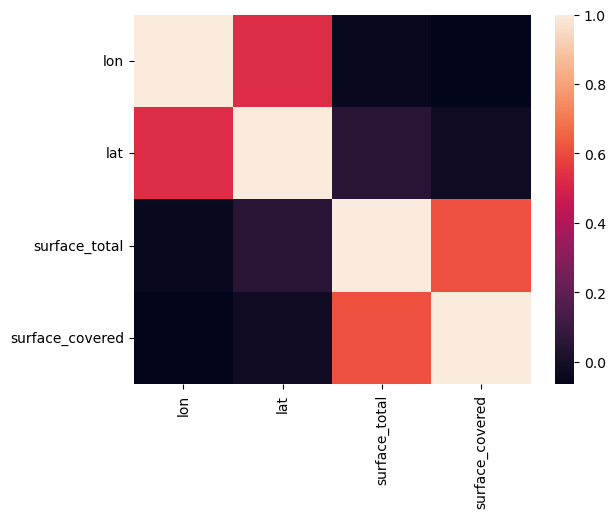

In [18]:
corr = df_processed.select_dtypes("number").drop(columns="price_usd").corr()
sns.heatmap(corr);

### Split Data

In [19]:
target = "price_usd"

In [20]:
features= ["lat", "lon", "neighborhood", "surface_covered"]
X_train=df_processed[features]
y_train=df_processed[target]

## Build Model

### Baseline

In [21]:
y_mean = y_train.mean()
print("Mean property price:", y_mean)
y_pred_baseline = [y_mean]*len(y_train)
print("Baseline MAE:", mean_absolute_error(y_train,y_pred_baseline))

Mean property price: 1059141.767521191
Baseline MAE: 469877.2396421886


### Iterate

In [22]:
# from category_encoders import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [23]:
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[("num", SimpleImputer(strategy="median"), num_cols), ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                                                                             OneHotEncoder(handle_unknown="ignore")), cat_cols)])
# Complete model
model = make_pipeline(preprocessor, Ridge())

# Fit
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred_training = model.predict(X_train)
print("Training MAE:", mean_absolute_error(y_train, y_pred_training))

Training MAE: 366137.1806015615


## Communicate Results

In [25]:
def make_prediction(area, lat, lon, neighborhood):
    data = {"surface_covered":area, "lat":lat, "lon":lon, "neighborhood":neighborhood}
    
    df_processed=pd.DataFrame(data,index=[0])
    prediction = model.predict(df_processed).round(2)
    return f"Predicted property price: ${prediction}"

In [26]:
make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted property price: $[118888.48]'

In [27]:
interact(
    make_prediction,
    area=IntSlider(
        min=X_train["surface_covered"].min(),
        max=X_train["surface_covered"].max(),
        value=X_train["surface_covered"].mean(),
    ),
    lat=FloatSlider(
        min=X_train["lat"].min(),
        max=X_train["lat"].max(),
        step=0.01,
        value=X_train["lat"].mean(),
    ),
    lon=FloatSlider(
        min=X_train["lon"].min(),
        max=X_train["lon"].max(),
        step=0.01,
        value=X_train["lon"].mean(),
    ),
    neighborhood=Dropdown(options=sorted(X_train["neighborhood"].unique())),
);

interactive(children=(IntSlider(value=264, description='area', max=689, min=116), FloatSlider(value=-34.593727…

## Author

<a href="https://www.linkedin.com/in/andrew-kalumba-harris/">ANDREW KALUMBA YIGGA</a><br>
<a href =""> </a>


| Date (YYYY-MM-DD) | Prepared By     | 
| ----------------- | --------------  | 
| 2026-08-16        | Author          | 


## <h3 align="center">  Data Science 2026. <h3/>